<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/pipes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
import pandas as pd
import numpy as np
import seaborn as sns

In [139]:
df = pd.DataFrame(pd.read_csv('/content/Mental Health Dataset.csv')).drop(columns = 'Timestamp')
df.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [140]:
df = df[df['care_options'] != 'Not Sure']

In [141]:
X = df.drop(columns = ['care_options'])
y = df['care_options']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 23)
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

['No' 'No' 'Yes' 'Yes' 'No']
              precision    recall  f1-score   support

          No       0.78      0.72      0.75     23940
         Yes       0.68      0.74      0.71     19080

    accuracy                           0.73     43020
   macro avg       0.73      0.73      0.73     43020
weighted avg       0.73      0.73      0.73     43020

Axes(0.125,0.11;0.62x0.77)


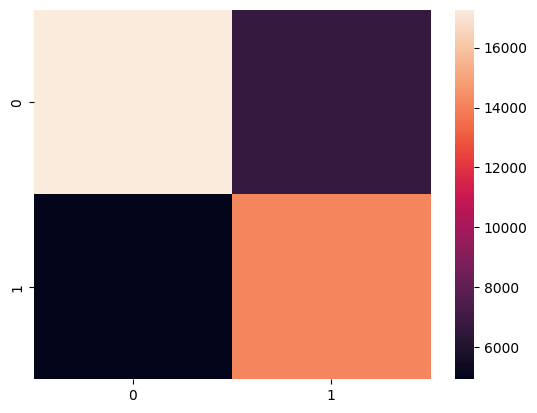

In [154]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import KNNImputer, SimpleImputer # Added SimpleImputer
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, LogisticRegression # Added LogisticRegression
from sklearn.feature_selection import SelectFromModel # Import SelectFromModel

prep_cat = Pipeline(steps =[
    ('imputer_cat', SimpleImputer(strategy='constant', fill_value='missing')), # Impute missing categorical values
    ('encoder', OneHotEncoder(sparse_output = False, handle_unknown='ignore')) # handle_unknown='ignore' for robust encoding
    ])

prep_num = Pipeline(steps = [
    ('imputer_num', SimpleImputer(strategy = 'constant', fill_value = 'missing')),
    ('scaler', StandardScaler())
])

#(AI) FEATS FROM X_TRAIN
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(transformers = [
    ('num', prep_num, num_features),
    ('enc', prep_cat, cat_features)
])

# Filter out 'Not sure' from training and testing data
train_mask = y_train != 'Not sure'
X_train_filtered = X_train[train_mask]
y_train_filtered = y_train[train_mask]

test_mask = y_test != 'Not sure'
X_test_filtered = X_test[test_mask]
y_test_filtered = y_test[test_mask]

custom_weights = {'Yes': 1.0, 'No': 0.75}

#small pipeline
pipeline_1 = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer()),
    ('feature_selection', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000))),
    ('rf_clf', RandomForestClassifier(max_depth = 8, n_estimators = 100, class_weight=custom_weights))
    ])

pipeline_1.fit(X_train_filtered, y_train_filtered)
preds = pipeline_1.predict(X_test_filtered)
print(preds[0:5])

from sklearn.metrics import confusion_matrix,classification_report

def evaluate_res(y_test, y_preds):
  print(classification_report(y_test, y_preds))
  print(sns.heatmap(confusion_matrix(y_test, y_preds)))

# Call the evaluation function AFTER making predictions
evaluate_res(y_test_filtered, preds)